In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Y1.jpg to Y1 (1).jpg
Saving Y2.jpg to Y2 (1).jpg
Saving Y3.jpg to Y3 (1).jpg
Saving Y4.jpg to Y4 (1).jpg
Saving Y6.jpg to Y6 (1).jpg
Saving Y7.jpg to Y7 (1).jpg
Saving Y8.jpg to Y8 (1).jpg
Saving Y9.jpg to Y9 (1).jpg
Saving Y10.jpg to Y10 (1).jpg
Saving Y11.jpg to Y11 (1).jpg
Saving Y12.jpg to Y12 (1).jpg
Saving Y13.jpg to Y13 (1).jpg
Saving Y14.jpg to Y14 (1).jpg
Saving Y15.jpg to Y15 (1).jpg
Saving Y16.JPG to Y16 (1).JPG
Saving Y17.jpg to Y17 (1).jpg
Saving Y18.JPG to Y18 (1).JPG
Saving Y19.JPG to Y19 (1).JPG
Saving Y20.jpg to Y20 (1).jpg
Saving Y21.jpg to Y21 (1).jpg
Saving Y22.jpg to Y22 (1).jpg
Saving Y23.JPG to Y23 (1).JPG
Saving Y24.jpg to Y24 (1).jpg
Saving Y25.jpg to Y25 (1).jpg
Saving Y26.jpg to Y26 (1).jpg
Saving Y27.jpg to Y27 (1).jpg
Saving Y28.jpg to Y28 (1).jpg
Saving Y29.jpg to Y29 (1).jpg
Saving Y30.jpg to Y30 (1).jpg
Saving Y31.jpg to Y31 (1).jpg
Saving Y32.jpg to Y32 (1).jpg
Saving Y33.jpg to Y33 (1).jpg
Saving Y34.jpg to Y34 (1).jpg
Saving Y35.jpg to Y35 (1).

In [ ]:
!unzip brain_tumor_dataset.zip

Archive:  brain_tumor_dataset.zip
replace brain_tumor_dataset/no/1 no.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace brain_tumor_dataset/no/10 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace brain_tumor_dataset/no/11 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace brain_tumor_dataset/no/12 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: one
error:  invalid response [one]
replace brain_tumor_dataset/no/12 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace brain_tumor_dataset/no/12 no.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,activation='sigmoid'))

In [ ]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [ ]:
history = model.fit(
train_data,
epochs=10,
validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 948ms/step - accuracy: 0.7143 - loss: 0.5599 - val_accuracy: 0.7400 - val_loss: 0.5469
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8128 - loss: 0.5032 - val_accuracy: 0.7400 - val_loss: 0.5322
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 984ms/step - accuracy: 0.7882 - loss: 0.4879 - val_accuracy: 0.7400 - val_loss: 0.5557
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8177 - loss: 0.4376 - val_accuracy: 0.7400 - val_loss: 0.4997
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 884ms/step - accuracy: 0.8522 - loss: 0.4063 - val_accuracy: 0.7400 - val_loss: 0.4838
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8670 - loss: 0.3460 - val_accuracy: 0.8000 - val_loss: 0.5655
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 913ms/step - accuracy: 0.8571 - loss: 0.3236 - val_accuracy: 0.7800 - val_loss: 0.4462
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 877ms/step - accuracy: 0.9015 - loss: 0.2586 - val_accuracy: 0.8000 - val_loss: 0.5150


In [ ]:
loss, acc = model.evaluate(val_data)

print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8000 - loss: 0.4465
Validation Accuracy: 0.800000011920929


In [ ]:
img, label = next(val_data)

prediction = model.predict(img)

print("Predicted:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
Predicted: [0.61796075]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

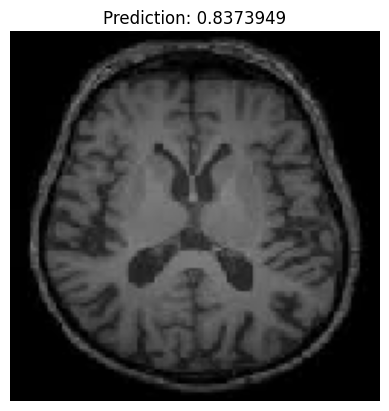

In [ ]:
img, label = next(val_data)

prediction = model.predict(img)

plt.imshow(img[0])
plt.title("Prediction: " + str(prediction[0][0]))
plt.axis("off")